# Week 3: Supervised learning — regression and model training

**Applied Machine Learning for Business**

Run cells from top to bottom. This notebook combines short numerical exercises with a stock-series practical. Use Python with `numpy`, `pandas`, `matplotlib`, and `scikit-learn` installed. Put `stock_data.csv` in the same working folder as this notebook. The supplied `.py` file runs the same code from its own folder.

**Dataset:** simulated stock price series from [mrsimple07, Stock Price Prediction (Kaggle)](https://www.kaggle.com/datasets/mrsimple07/stock-price-prediction). The file has 365 calendar dates and five unnamed series (`Stock_1` to `Stock_5`); it contains neither real company identifiers nor currency metadata. Treat the values as price units. The numbers reproduce multiplicative random walks generated with NumPy seed 0; they should not be described as genuine exchange observations. No network or price API is needed.

**Forecasting question:** after observing today's recorded `Stock_1` value, predict its value on the next recorded date. A correct prediction exercise does not establish a profitable investment strategy.

**Learning goals:** explain a regression equation and its errors; perform one gradient update; construct past-only features; separate training, validation, and final testing; compare linear regression and Ridge with a simple baseline.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
OUT = BASE_DIR / "outputs"
OUT.mkdir(exist_ok=True)

## 1. A prediction equation and its errors

In a small teaching example, the candidate model predicts sales from advertising spend: **prediction = 1 + 1 × spend**. Spend is in hundreds of dollars and sales in hundreds of units. The intercept and slope are both 1. Here, residual means predicted minus actual. MSE squares errors, while MAE uses their absolute values.

**Practice 1 — prediction errors (6 minutes; slides 11–12):** before running the next cell, use `spend = [0, 1, 2]`, `sales = [1, 3, 5]`, and the candidate equation `prediction = 1 + spend`. Calculate all three predictions, the errors (`prediction − actual`), MAE, and MSE. Explain why the squared-error column weights larger errors more strongly. Run the cell to check your work.

In [2]:
spend = np.array([0.0, 1.0, 2.0])
sales = np.array([1.0, 3.0, 5.0])
predicted = 1 + 1 * spend
errors = predicted - sales
toy_table = pd.DataFrame({"spend": spend, "actual": sales,
                          "predicted": predicted, "error": errors,
                          "squared_error": errors ** 2})
print(toy_table.to_string(index=False))
print("MAE:", np.mean(np.abs(errors)))
print("MSE:", np.mean(errors ** 2))

 spend  actual  predicted  error  squared_error
   0.0     1.0        1.0    0.0            0.0
   1.0     3.0        2.0   -1.0            1.0
   2.0     5.0        3.0   -2.0            4.0
MAE: 1.0
MSE: 1.6666666666666667


**Optional arithmetic check:** calculate the predictions and MSE for `prediction = 1 + 2 × spend`. Which of the two supplied lines has lower MSE on these three observations? Comparing fit on these observations alone does not measure performance on new cases.

## 2. One gradient descent update

Continue the same invented example with `x = [0, 1, 2]` and `y = [1, 3, 5]`. Start with slope `w = 1` and intercept `b = 1`. For MSE, the gradients are `2 × mean((prediction − y) × x)` for `w` and `2 × mean(prediction − y)` for `b`. Both updates use the gradients at the old parameters.

In [3]:
x = np.array([0.0, 1.0, 2.0])
y = np.array([1.0, 3.0, 5.0])
w, b, learning_rate = 1.0, 1.0, 0.15
prediction = w * x + b
gradient_w = 2 * np.mean((prediction - y) * x)
gradient_b = 2 * np.mean(prediction - y)
w = w - learning_rate * gradient_w
b = b - learning_rate * gradient_b
print(f"New slope = {w:.4f}; new intercept = {b:.4f}")
print(f"New MSE = {np.mean((w * x + b - y) ** 2):.4f}")

New slope = 1.5000; new intercept = 1.3000
New MSE = 0.2067


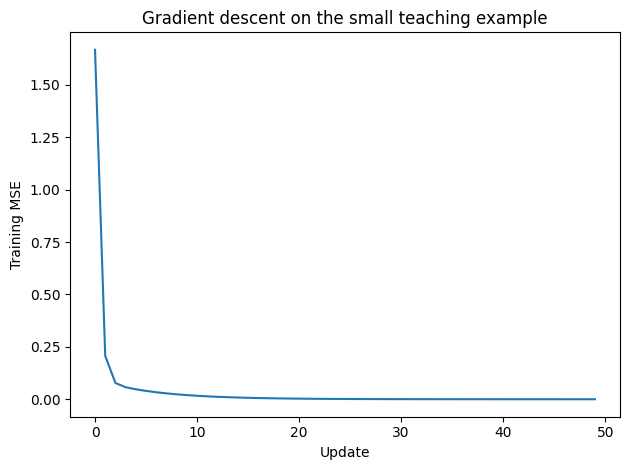

In [4]:
w, b = 1.0, 1.0
losses = []
for step in range(50):
    prediction = w * x + b
    losses.append(float(np.mean((prediction - y) ** 2)))
    gradient_w = 2 * np.mean((prediction - y) * x)
    gradient_b = 2 * np.mean(prediction - y)
    w, b = w - learning_rate * gradient_w, b - learning_rate * gradient_b
plt.plot(range(50), losses)
plt.xlabel("Update"); plt.ylabel("Training MSE")
plt.title("Gradient descent on the small teaching example")
plt.tight_layout(); plt.savefig(OUT / "gradient_descent.png"); plt.show()

**Optional instructor demonstration — learning rate:** try learning rates `0.01` and `0.5` in the iteration cell. Explain why a larger step need not improve learning. Restore `learning_rate = 0.15` afterward. Scikit-learn's ordinary `LinearRegression` uses a least-squares solver; this gradient descent demonstration explains a general training principle and is not that estimator's internal algorithm.

## 3. Inspect the supplied data

The first CSV column stores dates, although its header is blank. Read it as the index and sort it. Check missing values and the number of observations before modeling. All five columns are available in the file; the main exercise models `Stock_1`.

In [5]:
import pandas as pd

In [6]:
prices = pd.read_csv(BASE_DIR / "stock_data.csv",
                     index_col=0, parse_dates=True).sort_index()

#OR LOAD WITH CURRENT WORKING DIRECTORY
''' prices = pd.read_csv(
    "stock_data.csv",
    index_col=0,
    parse_dates=True
).sort_index()
'''
prices.index.name = "Date"
print(prices.head().round(3).to_string())
print("Shape:", prices.shape)
print("Dates:", prices.index.min().date(), "to", prices.index.max().date())
print("Missing values:", int(prices.isna().sum().sum()))
assert prices.index.is_unique and prices.index.is_monotonic_increasing
assert prices.notna().all().all()

            Stock_1  Stock_2  Stock_3  Stock_4  Stock_5
Date                                                   
2020-01-01  101.764  100.161   99.495   99.910  101.761
2020-01-02  102.171   99.970   98.683  100.641  102.529
2020-01-03  103.171   99.575   98.182  100.575  101.888
2020-01-04  105.483   99.309   97.149  100.925  101.490
2020-01-05  107.453   98.188   99.575  101.594  101.604
Shape: (365, 5)
Dates: 2020-01-01 to 2020-12-30
Missing values: 0


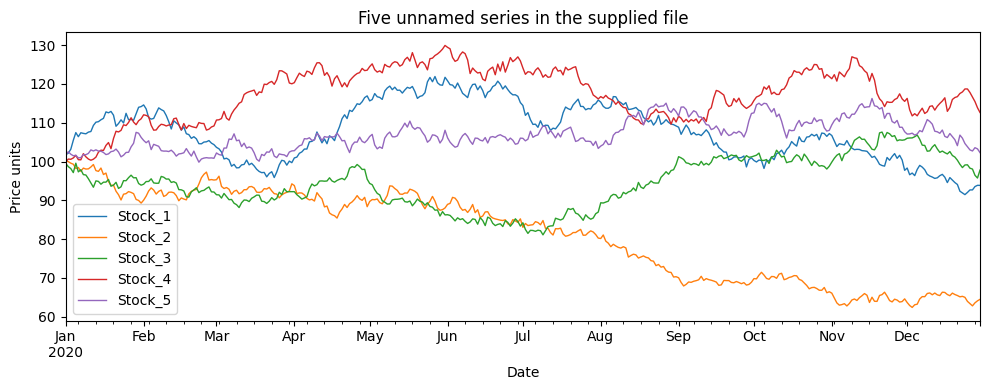

In [7]:
prices.plot(figsize=(10, 4), linewidth=1)
plt.ylabel("Price units")
plt.title("Five unnamed series in the supplied file")
plt.tight_layout()
plt.savefig(OUT / "supplied_series.png")
plt.show()

**Optional data inspection check:** inspect the first and last records and describe one visible pattern. Check whether the file includes weekend dates. Explain why column names such as `Stock_1` do not identify real companies.

## 4. Turn a sequence into supervised examples

For an input dated day *t*, the known current value is `Stock_1[t]`. Features are that value, the previous value, and the mean of the latest five known values. The target is the next recorded value. `shift(-1)` is used only to construct the target; it must not be used to create an input feature.

The first four rows have no five-record average, and the last row has no known target. Keep the original `prices` table so the last observation can still be used for an illustrative future prediction.

In [8]:
data = prices.copy()
data["lag_1"] = prices["Stock_1"].shift(1)
data["mean_5"] = prices["Stock_1"].rolling(5).mean()
data["target"] = prices["Stock_1"].shift(-1)
data["target_date"] = prices.index.to_series().shift(-1)
data = data.dropna()
features = ["Stock_1", "lag_1", "mean_5"]
print(data[features + ["target", "target_date"]].head().round(3).to_string())

            Stock_1    lag_1   mean_5   target target_date
Date                                                      
2020-01-05  107.453  105.483  104.009  106.403  2020-01-06
2020-01-06  106.403  107.453  104.936  107.414  2020-01-07
2020-01-07  107.414  106.403  105.985  107.251  2020-01-08
2020-01-08  107.251  107.414  106.801  107.141  2020-01-09
2020-01-09  107.141  107.251  107.132  107.581  2020-01-10


C:\Users\baiys\AppData\Local\Temp\ipykernel_2312\2897540379.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(data[features + ["target", "target_date"]].head().round(3).to_string())


## 5. Respect time in training and evaluation

Use cutoffs at 60% and 80% of the original recorded dates. Training fits the model; validation compares choices; the final test estimates performance after the choice is fixed. The row immediately before each cutoff is omitted because its target falls into the next period. Validation/test features may use older observed history, because that history is available at prediction time.

This is a sequence of **one-step forecasts with newly observed values available each day**. It is not a multi-day forecast made entirely from the first test date. Do not shuffle the rows.

In [9]:
valid_start = prices.index[int(len(prices) * 0.60)]
test_start = prices.index[int(len(prices) * 0.80)]
train = data[data["target_date"] < valid_start]
valid = data[(data.index >= valid_start) & (data["target_date"] < test_start)]
test = data[data.index >= test_start]
for name, part in [("Train", train), ("Validation", valid), ("Test", test)]:
    print(name, len(part), part.index.min().date(), part.index.max().date())
assert train["target_date"].max() < valid.index.min()
assert valid["target_date"].max() < test.index.min()

Train 214 2020-01-05 2020-08-05
Validation 72 2020-08-07 2020-10-17
Test 72 2020-10-19 2020-12-29


**Practice 2 — audit the features and split (7 minutes; slide 31):** the forecast is made after today's value is observed. Inspect three rows and explain which date each feature uses. Decide which inputs are valid: (a) today's Stock_1 value, (b) `Stock_1.shift(1)`, (c) `Stock_1.shift(-1)`, and (d) `Stock_1.rolling(5, center=True).mean()`. Explain each answer. Then identify the two input dates omitted at the train/validation and validation/test boundaries, and explain why their target dates cross the cutoffs. Do not fit a model for this audit.

## 6. Establish a baseline, then fit simple regression

The persistence baseline predicts that the next value equals the current value. A model is useful only if its measured performance justifies using it. MAE is in price units. RMSE gives relatively more weight to large errors.

In [10]:
baseline_valid = valid["Stock_1"]
baseline_mae = mean_absolute_error(valid["target"], baseline_valid)
print(f"Validation baseline MAE: {baseline_mae:.4f}")

Validation baseline MAE: 0.8263


In [11]:
simple = LinearRegression()
simple.fit(train[["Stock_1"]], train["target"])
simple_valid = simple.predict(valid[["Stock_1"]])
simple_mae = mean_absolute_error(valid["target"], simple_valid)
print(f"Intercept: {simple.intercept_:.4f}")
print(f"Slope: {simple.coef_[0]:.4f}")
print(f"Validation regression MAE: {simple_mae:.4f}")

Intercept: 1.3734
Slope: 0.9880
Validation regression MAE: 0.8282


**Optional fitted-equation check:** write this fitted equation in words, calculate its prediction for a current value of 110, and compare its validation MAE with the baseline. A coefficient describes an association learned here; it does not establish a causal effect.

## 7. Add features and introduce regularization

Multiple regression estimates one coefficient per input. More features may lower training error without improving validation performance. The current value, yesterday's value, and their recent average overlap, so individual coefficients can be unstable.

In [12]:
multiple = LinearRegression()
multiple.fit(train[features], train["target"])
multiple_valid = multiple.predict(valid[features])
multiple_mae = mean_absolute_error(valid["target"], multiple_valid)
print(pd.Series(multiple.coef_, index=features).round(4).to_string())
print(f"Validation multiple-regression MAE: {multiple_mae:.4f}")

Stock_1    1.0139
lag_1      0.0304
mean_5    -0.0573
Validation multiple-regression MAE: 0.8314


Ridge adds a penalty for large coefficients. Scaling makes its penalty comparable across features. The pipeline fits both scaling and Ridge using training data only. Use validation MAE to choose `alpha`. Larger `alpha` means a stronger penalty. This is a small introduction to tuning; cross validation is developed later.

In [13]:
ridge_models, ridge_rows = {}, []
for alpha in [0.01, 0.1, 1, 10, 100]:
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(train[features], train["target"])
    predicted = model.predict(valid[features])
    mae = mean_absolute_error(valid["target"], predicted)
    ridge_models[alpha] = model
    ridge_rows.append({"alpha": alpha, "validation_MAE": mae})
ridge_results = pd.DataFrame(ridge_rows)
best_alpha = float(ridge_results.loc[ridge_results["validation_MAE"].idxmin(), "alpha"])
print(ridge_results.round(4).to_string(index=False))

 alpha  validation_MAE
  0.01          0.8311
  0.10          0.8286
  1.00          0.8211
 10.00          0.8589
100.00          1.2026


**Practice 3 — change the rolling window (8 minutes; slide 41):** in a separate copy of the feature-building exercise, replace the five-record trailing mean with a ten-record trailing mean. Compare persistence, simple regression, multiple regression, and Ridge using training and validation only. For a fair five-versus-ten comparison, refit all candidates on the same common nonmissing dates and preserve the cutoffs based on the original 365 records. Keep all extension variable names separate from the main experiment. Record the best validation choice and explain the result. **Do not inspect or recompute final-test scores for this extension.** The instructor solution contains the exact comparison on common dates.

Use the supplied scaffold for this short in-class exercise:

```python
from Week_3_Practice_3_Starter import compare_windows
compare_windows(windows=(5, 10))
```

Read the helper’s `rolling(window)` line and explain the common-date comparison. Keep this extension separate from the original guided experiment.


## 8. Make the choice before inspecting the final test

Compare the best Ridge candidate with ordinary regression and the baseline on the same validation examples. An improvement of a few thousandths of a price unit is small; it may not repeat on future data.

In [14]:
validation_results = pd.DataFrame([
    {"strategy": "Persistence baseline", "validation_MAE": baseline_mae},
    {"strategy": "Simple regression", "validation_MAE": simple_mae},
    {"strategy": "Multiple regression", "validation_MAE": multiple_mae},
    {"strategy": "Ridge", "validation_MAE": ridge_results["validation_MAE"].min()}
]).sort_values("validation_MAE").reset_index(drop=True)
selected_name = validation_results.loc[0, "strategy"]
print(validation_results.round(4).to_string(index=False))
print("Frozen selection:", selected_name, "; Ridge alpha:", best_alpha)

            strategy  validation_MAE
               Ridge          0.8211
Persistence baseline          0.8263
   Simple regression          0.8282
 Multiple regression          0.8314
Frozen selection: Ridge ; Ridge alpha: 1.0


**Optional after-class extension — another observed series:** create a copy of the multiple-regression experiment with `Stock_2` added. Fit only on `train` and compare only on `valid`. Record the input list, validation MAE, and your interpretation. Keep this extension separate from the main experiment below so the fixed lesson results remain reproducible. Do not choose features or `alpha` from final-test results.

**In the core lesson, skip this optional extension and pause here until the instructor opens the final test.** The rest of the notebook evaluates the original frozen selection. Make no further model changes in response to that result.

In [15]:
models = {"Simple regression": (simple, ["Stock_1"]),
          "Multiple regression": (multiple, features),
          "Ridge": (ridge_models[best_alpha], features)}
if selected_name == "Persistence baseline":
    final_pred = test["Stock_1"].to_numpy()
else:
    chosen_model, chosen_features = models[selected_name]
    final_pred = chosen_model.predict(test[chosen_features])
test_rows = []
for name, predicted in [("Persistence baseline", test["Stock_1"]),
                        (selected_name, final_pred)]:
    test_rows.append({"strategy": name,
        "test_MAE": mean_absolute_error(test["target"], predicted),
        "test_RMSE": np.sqrt(mean_squared_error(test["target"], predicted))})
test_results = pd.DataFrame(test_rows).drop_duplicates("strategy")
print(test_results.round(4).to_string(index=False))

            strategy  test_MAE  test_RMSE
Persistence baseline    0.7324     0.9111
               Ridge    0.7800     0.9690


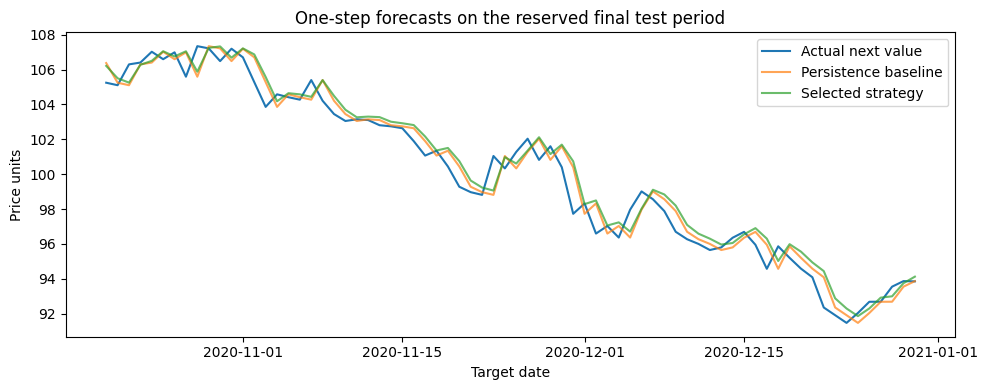

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(test["target_date"], test["target"], label="Actual next value")
plt.plot(test["target_date"], test["Stock_1"], label="Persistence baseline", alpha=0.7)
plt.plot(test["target_date"], final_pred, label="Selected strategy", alpha=0.7)
plt.xlabel("Target date"); plt.ylabel("Price units")
plt.title("One-step forecasts on the reserved final test period")
plt.legend(); plt.tight_layout()
plt.savefig(OUT / "final_test.png"); plt.show()

## 9. Interpret the result

The supplied data select Ridge with `alpha = 1` by validation MAE. Its final-test MAE is about **0.7800**, compared with **0.7324** for persistence. The learned model does not beat the baseline on the final test. A close-looking line plot alone is insufficient evidence of success.

Discuss: Does adding a model create business value here? What additional evidence would be required? What changes in data or context might make this result fail to transfer? This exercise measures forecast errors, not trading returns.

## 10. Predict after the final recorded observation

Once evaluation is complete, an illustrative deployment model can refit the already selected strategy on all labeled history. Keep the same features and `alpha`. This refit creates no new test result. The next observation's date and actual value are absent from the file, so label the output as a prediction for the **next recorded observation after 2020-12-30**.

In [17]:
latest = pd.DataFrame({"Stock_1": [prices["Stock_1"].iloc[-1]],
                       "lag_1": [prices["Stock_1"].iloc[-2]],
                       "mean_5": [prices["Stock_1"].iloc[-5:].mean()]})
if selected_name == "Persistence baseline":
    next_prediction = float(latest["Stock_1"].iloc[0])
else:
    from sklearn.base import clone
    deployment_model = clone(chosen_model).fit(data[chosen_features], data["target"])
    next_prediction = float(deployment_model.predict(latest[chosen_features])[0])
print("Last observed date:", prices.index[-1].date())
print(f"Illustrative next recorded value: {next_prediction:.4f} price units")

Last observed date: 2020-12-30
Illustrative next recorded value: 93.8900 price units


**Closing discussion — 4 minutes:** give a short business explanation covering the prediction time, input features, baseline, final-test evidence, and one limitation of the dataset. Explain why `target`, tomorrow's value, or a centered moving average must not be included as model inputs.

**Core lesson practice:** Practice 1 (6 minutes), Practice 2 (7 minutes), Practice 3 (8 minutes), and closing discussion (4 minutes). All other checks are optional or instructor demonstrations and add no required core lesson time. The instructor solution is provided separately. For a longer extension, repeat the whole design on another supplied series, setting aside a new final test before experimentation.

## Reproducibility outputs

The following cell saves output tables and plotting data used in the course slides. It introduces no additional fitting or test-based selection.

In [18]:
validation_results.to_csv(OUT / "validation_results.csv", index=False)
ridge_results.to_csv(OUT / "ridge_validation.csv", index=False)
test_results.to_csv(OUT / "test_results.csv", index=False)
predictions = pd.DataFrame({"input_date": test.index,
    "target_date": test["target_date"].to_numpy(), "actual": test["target"].to_numpy(),
    "baseline": test["Stock_1"].to_numpy(), "selected": final_pred})
predictions.to_csv(OUT / "test_predictions.csv", index=False)
summary = {
    "dataset": {"rows": len(prices), "columns": list(prices.columns),
        "first_date": str(prices.index.min().date()), "last_date": str(prices.index.max().date()),
        "missing": int(prices.isna().sum().sum()), "weekend_rows": int((prices.index.dayofweek >= 5).sum())},
    "split": {name: {"rows": len(part), "first_input": str(part.index.min().date()),
        "last_input": str(part.index.max().date()), "first_target": str(part.target_date.min().date()),
        "last_target": str(part.target_date.max().date())}
        for name, part in [("train", train), ("validation", valid), ("test", test)]},
    "excluded_boundary_input_dates": [str((valid_start - pd.Timedelta(days=1)).date()),
                                      str((test_start - pd.Timedelta(days=1)).date())],
    "simple_intercept": float(simple.intercept_), "simple_slope": float(simple.coef_[0]),
    "multiple_coefficients": dict(zip(features, multiple.coef_.tolist())),
    "validation": validation_results.to_dict(orient="records"),
    "ridge_validation": ridge_results.to_dict(orient="records"),
    "selected_name": str(selected_name), "best_alpha": best_alpha,
    "test": test_results.to_dict(orient="records"), "next_prediction_after_refit": next_prediction,
    "last_observation": float(prices["Stock_1"].iloc[-1])}
(OUT / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
chart_data = {"series": {"dates": prices.index.strftime("%Y-%m-%d").tolist(),
    **{col: prices[col].tolist() for col in prices.columns}},
    "test": {"dates": test.target_date.dt.strftime("%Y-%m-%d").tolist(),
        "actual": test.target.tolist(), "baseline": test.Stock_1.tolist(), "ridge": final_pred.tolist()},
    "gradient_descent": {"updates": list(range(50)), "loss": losses},
    "training_scatter": {"current": train.Stock_1.tolist(), "next": train.target.tolist(),
        "intercept": float(simple.intercept_), "slope": float(simple.coef_[0])},
    "validation": validation_results.to_dict(orient="records"),
    "ridge_validation": ridge_results.to_dict(orient="records"),
    "toy_errors": toy_table.to_dict(orient="records")}
(OUT / "chart_data.json").write_text(json.dumps(chart_data, indent=2), encoding="utf-8")
print("Saved output tables, summary, and chart data in", OUT)

Saved output tables, summary, and chart data in e:\Документы\GitHub\Week_3_Regression_Practical\outputs
